Matching Labels over total score for each of the 5 papers

Models used were Gemini 2.5 Pro, Sonnet 4, and GPT-4.1

Five papers used for benchmarking

Cunningham et al. (https://pubs.acs.org/doi/10.1021/acs.oprd.2c00268?ref=PDF)

Adlington et al. (https://pubs.acs.org/doi/10.1021/acs.oprd.1c00475)

Naganathan et al., (https://pubs.acs.org/doi/10.1021/acs.oprd.5b00037)

Duan et al., (https://pubs.acs.org/doi/10.1021/op300262z)

Kempson et al. (https://pubs.acs.org/doi/10.1021/acs.oprd.2c00036)


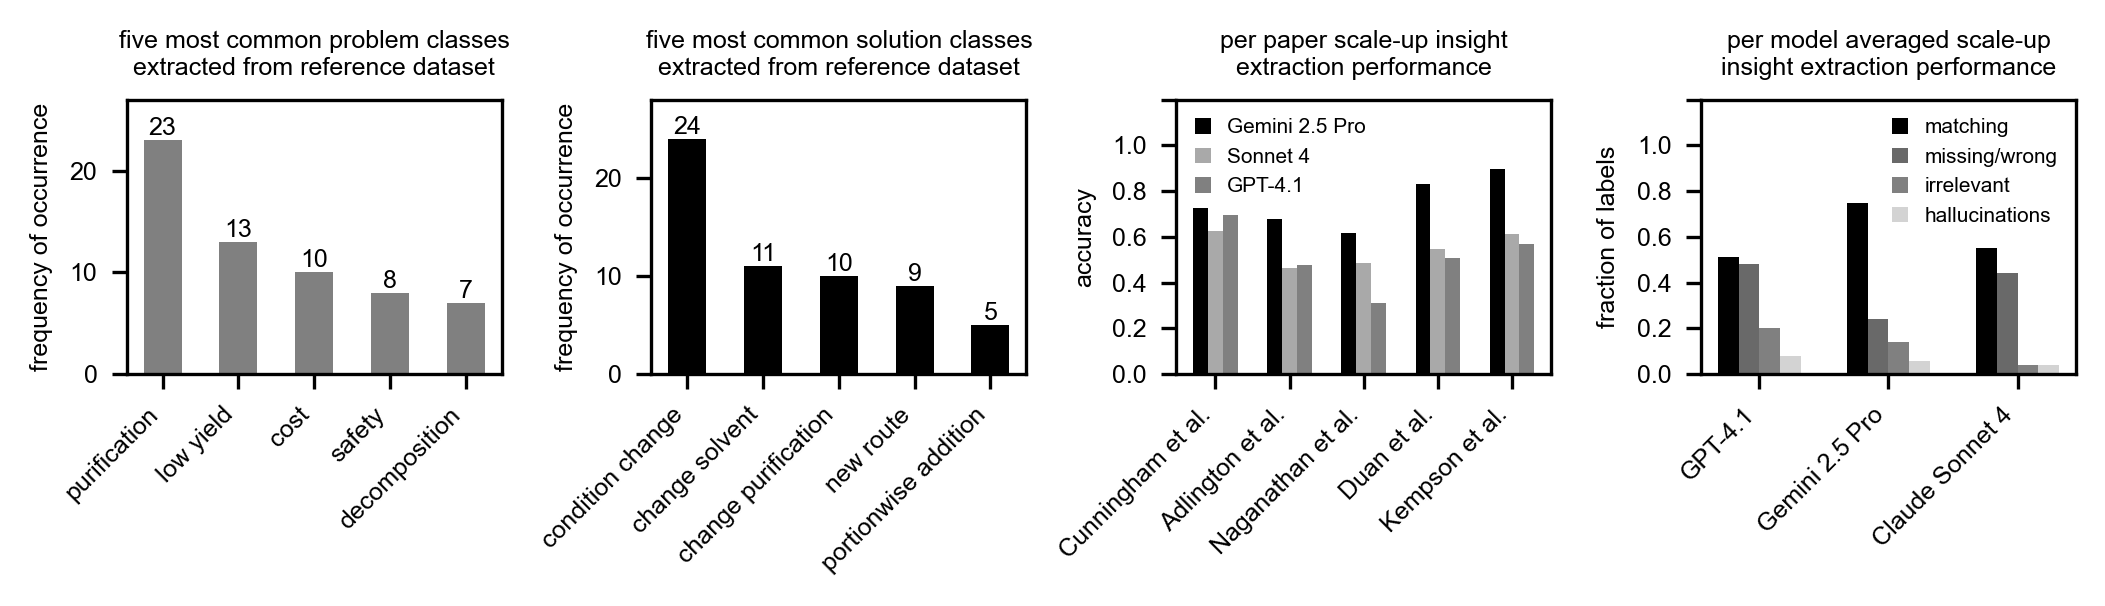

In [191]:
from matplotlib import pyplot as plt
import numpy as np

fig,ax = plt.subplots(1,4,figsize=(7,2), dpi=300)
plt.rc('font', size=6)
plt.rc('font', family='Arial')


gemini = [10.9/15, 14.2/21, 36.6/59.5, 30.3/36.5, 19.7/22]
gpt = [10.4/15, 10/21, 18.5/59.5, 18.5/36.5, 12.5/22]
sonnet = [9.4/15, 9.75/21, 29/59.5, 20/36.5, 13.5/22]
labels = ['Cunningham et al.', 'Adlington et al.', 'Naganathan et al.', 'Duan et al.', 'Kempson et al.']

x = np.arange(len(labels))
width = 0.2

ax[2].bar(x - width, gemini, width, label='Gemini 2.5 Pro', color='black')
ax[2].bar(x, sonnet, width, label='Sonnet 4', color='darkgray')
ax[2].bar(x + width, gpt, width, label='GPT-4.1', color='gray')
ax[2].set_xticks(x, labels, rotation=45, ha='right')
ax[2].set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2])
ax[2].set_yticklabels(["0.0", "0.2", "0.4", "0.6", "0.8", "1.0", ""])
ax[2].set_ylabel('accuracy')
ax[2].set_title('per paper scale-up insight\nextraction performance', fontsize=6)
# ax[0].set_xlabel("paper assessed")
leg = ax[2].legend(loc='upper left', fontsize=5, handlelength=0.75, handleheight=0.75, frameon=False)


labels = ["purification", "low yield", "cost", "safety", "decomposition"]
count = [23, 13, 10, 8, 7]  # frequency of each problem in the reference dataset

x = np.arange(len(labels))
width = 0.5

bars = ax[0].bar(x, count, width, color='grey')
ax[0].set_xticks(x, labels, rotation=45, ha='right')
ax[0].set_ylabel('frequency of occurrence')
# ax[1].set_xlabel("problem class")
ax[0].set_title('five most common problem classes\nextracted from reference dataset', fontsize=6)
ax[0].bar_label(bars, padding=0, fontsize=6)
ax[0].set_ylim(0, 27)


labels = ["condition change", "change solvent", "change purification", "new route", "portionwise addition"]
count = [24, 11, 10, 9, 5]

x = np.arange(len(labels))

bars = ax[1].bar(x, count, width, color='black')
ax[1].set_xticks(x, labels, rotation=45, ha='right')
ax[1].set_ylabel('frequency of occurrence')
# ax[2].set_xlabel("solution class")
ax[1].set_title('five most common solution classes\nextracted from reference dataset', fontsize=6)
ax[1].bar_label(bars, padding=0, fontsize=6)
ax[1].set_ylim(0, 28)


models = ["GPT-4.1", "Gemini 2.5 Pro", "Claude Sonnet 4"]
matching = [0.51, 0.75, 0.55]
missing = [0.48, 0.24, 0.44]
irrelevant = [0.20, 0.14, 0.04]
hallucinations = [0.08, 0.056, 0.04]

x = np.arange(len(models))
width = 0.16

b1 = ax[3].bar(x - 1.5*width, matching, width, label='matching', color='black')
b2 = ax[3].bar(x - 0.5*width, missing, width, label='missing/wrong', color='dimgray')
b3 = ax[3].bar(x + 0.5*width, irrelevant, width, label='irrelevant', color='gray')
b4 = ax[3].bar(x + 1.5*width, hallucinations, width, label='hallucinations', color='lightgray')

ax[3].set_xticks(x, models, rotation=45, ha='right')
ax[3].set_ylabel('fraction of labels')
ax[3].set_title('per model averaged scale-up\ninsight extraction performance', fontsize=6)
ax[3].set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2])
ax[3].set_yticklabels(["0.0", "0.2", "0.4", "0.6", "0.8", "1.0", ""])

# for bars in [b1, b2, b3, b4]:
    # ax[3].bar_label(bars, padding=0, fontsize=5, fmt='%.2f')

ax[3].legend(loc='upper right', fontsize=5, handlelength=0.75, handleheight=0.75, frameon=False)

# plt.tight_layout()
# plt.savefig('scaleup_label_type_distribution_across_models.png', dpi=300, bbox_inches='tight', pad_inches=0.0)
# plt.show()



fig.tight_layout()
# fig.subplots_adjust(bottom=0.26, top=0.92, left=0.26, right=.99)
plt.savefig('scaleup_top5_solutions_reference.png', dpi=300, pad_inches=0.0)

\begin{table}[h!]
\centering
\caption*{\textbf{LLM Benchmarking Scores}}
\begin{tabular}{ccccc}
\toprule
Model & Matching Labels & Missing/Incorrect Labels & Irrelevant Labels & Hallucinations \\
\midrule
GPT-4.1 & 0.51 & 0.48 & 0.2 & 0.08 \\
Gemini 2.5 Pro & 0.75 & 0.24 & 0.14 & 0.056 \\
Claude Sonnet 4 & 0.55 & 0.44 & 0.04 & 0.04 \\
\bottomrule
\end{tabular}
\vspace{2 pt}
\subcaption*{All scores are label counts divided by total number of labels in the reference dataset}
\end{table}